# Глубокая Q-сеть, вариант многослойного перцептрона (<span style="color: green"> 10 баллов за основную часть + 4 балла за бонусную часть </span>)

#### Дедлайн (жёсткий) задания: 19 апреля, 23:59 UTC+3

#### При сдаче задания нужно данный файл, использованные файлы *.py, а также папки с логами и видео поместить в архив, сохраняя относительные пути, и послать архив в систему сдачи.

### <span style="color: red"> Если работа была списана и/или сделана LLM, то за работу ставится 0 баллов </span>. 


В данной домашней работе требуется обучить агента CartPole, используя несколько вариантов DQN &mdash; приближённого алгоритм Q-обучения c различными вариациями механизма _experience_ _replay_ и целевой сетью (_target network_) &mdash; и пронаблюдать, лучше ли подход DQN работает по сравнению с рассмотренными ранее в каком-либо аспекте.

# Работа выполнена: Тулупов Николай Дмитриевич, Б01-204.

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
import os
import random
from IPython.display import clear_output
from queue import deque
from IPython.display import HTML
from pathlib import Path

import gymnasium as gym
from gymnasium.wrappers import RecordVideo

import torch
import torch.nn as nn
from torch.optim.lr_scheduler import LambdaLR

import utils

In [31]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Создаем агента CartPole

In [32]:
def make_env():
    return gym.make(ENV_NAME, render_mode="rgb_array").unwrapped

In [33]:
ENV_NAME = 'CartPole-v1'

env = make_env()
env.reset()

state_shape = env.observation_space.shape
n_actions = env.action_space.n

In [34]:
print("размерность вектора состояний dim =", state_shape[0])
print("n_actions =", n_actions)

размерность вектора состояний dim = 4
n_actions = 2


# Приближённое Q-обучение: построение сети

Напишем несколько вариаций нейронной сети, способной переводить наблюдения в Q-ценности состояния. Так как агент устроен достаточно просто, не требуется сложная нейронная сеть. Будет достаточно MLP с небольшим количеством промежуточных слоев. Подробное описание можно найти в главах $4.1$ и $4.2$ пособия (https://arxiv.org/pdf/2201.09746.pdf)

**Вариации DQN**

<span style="color: green"> __(0.4 балла)__ </span>

In [35]:
class DQNAgent(nn.Module):
    def __init__(self, state_shape, n_actions, epsilon=0):

        super().__init__()
        self.epsilon = epsilon
        self.n_actions = n_actions
        self.state_shape = state_shape
        # Задайте структуру нейронной сети здесь.
        # Убедитесь в том, что здесь определёны все параметры агента.
        assert len(state_shape) == 1
        state_dim = state_shape[0]
        self.input = nn.Linear(state_dim, 128)
        self.output = nn.Linear(128, n_actions)

    def forward(self, state_t):
        """
        принимает наблюдение агента (тензор), возвращает qvalues (тензор)
        :параметр state_t: батч состояний, размерность = [batch_size, *state_dim=4]
        """
        # Используёте Вашу нейросеть для вычисления qvalues данного состояния state_t
        h = torch.relu(self.input(state_t))
        qvalues = self.output(h)

        if torch.is_grad_enabled(): assert qvalues.requires_grad, "qvalues должны быть torch tensor с возможностью дифференцирования"
        assert len(qvalues.shape) == 2 and qvalues.shape[0] == state_t.shape[0] and qvalues.shape[1] == self.n_actions

        return qvalues

    def get_qvalues(self, states):
        """
        Как forward, только работает на numpy arrays, не на тензорах
        """
        # Ваше решение
        model_device = next(self.parameters()).device
        states_t = torch.tensor(states, device=model_device, dtype=torch.float32)
        qvalues = self.forward(states_t)
            
        return qvalues.data.cpu().numpy()

    def sample_actions(self, qvalues):
        """
        Выбрать действия для данных qvalues. Использует эпсилон-жадную стратегию исследования среды.
        """
        epsilon = self.epsilon
        batch_size, n_actions = qvalues.shape

        best_actions = np.argmax(qvalues, axis=1)
        random_actions = np.random.randint(0, n_actions, size=batch_size)

        should_explore = np.random.choice([0, 1], batch_size, p=[1-epsilon, epsilon])
        return np.where(should_explore, random_actions, best_actions)

<span style="color: green"> __(0.8 балла)__ </span>

In [36]:
class TwinDQNAgent(nn.Module):
    def __init__(self, state_shape, n_actions, epsilon=0):
        super().__init__()
        self.epsilon = epsilon
        self.n_actions = n_actions
        self.state_shape = state_shape

        assert len(state_shape) == 1
        state_dim = state_shape[0]

        def build_net():
            return nn.Sequential(
                nn.Linear(state_dim, 128),
                nn.ReLU(),
                nn.Linear(128, n_actions)
            )

        # Две независимые сети Q
        self.q_net1 = build_net()
        self.q_net2 = build_net()
        # self.q_net2 = self.q_net1 не делаем т к это сломает идею TwinDQN

    def forward(self, state_t):
        """
        Возвращает qvalues обеих сетей
        """
        q1 = self.q_net1(state_t)
        q2 = self.q_net2(state_t)

        assert q1.shape == q2.shape
        return q1, q2

    def get_qvalues(self, states):
        model_device = next(self.parameters()).device
        states_t = torch.tensor(states, device=model_device, dtype=torch.float32)
        q1, q2 = self.forward(states_t) 

        return q1.data.cpu().numpy(), q2.data.cpu().numpy()       

    def sample_actions(self, qvalues):
        """
        Использует qvalues от одной из сетей для выбора действия
        """
        epsilon = self.epsilon
        batch_size, n_actions = qvalues.shape

        best_actions = np.argmax(qvalues, axis=1)
        random_actions = np.random.randint(0, n_actions, size=batch_size)

        should_explore = np.random.choice([0, 1], batch_size, p=[1-epsilon, epsilon])
        return np.where(should_explore, random_actions, best_actions)

<span style="color: green"> __(1 балл)__ </span>

In [37]:
class DuelingDQNAgent(nn.Module):
    def __init__(self, state_shape, n_actions, epsilon=0):
        super().__init__()
        self.epsilon = epsilon
        self.n_actions = n_actions
        self.state_shape = state_shape
        assert len(state_shape) == 1
        state_dim = state_shape[0]

        # Общая часть сети (shared backbone)
        self.shared_network = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU()
        )

        # Голова для значения (V(s))
        self.value_head = nn.Linear(128, 1)

        # Голова для преимущества (A(s,a))
        self.advantage_head = nn.Linear(128, n_actions)

    def forward(self, state_t):
        batch_size = state_t.shape[0]
        features = self.shared_network(state_t)

        # Комбинируем V(s) и A(s,a) для получения Q(s,a)

        state_values = self.value_head(features)  # [batch, 1]
        advantages = self.advantage_head(features) # [batch, n_actions]
        qvalues = state_values + (advantages - advantages.mean(dim=1, keepdim=True))

        if torch.is_grad_enabled(): assert qvalues.requires_grad, "qvalues должны быть torch tensor с возможностью дифференцирования"
        assert qvalues.shape == (batch_size, self.n_actions)

        return qvalues

    def get_qvalues(self, states):
        model_device = next(self.parameters()).device
        states_t = torch.tensor(states, device=model_device, dtype=torch.float32)
        qvalues = self.forward(states_t)
        return qvalues.data.cpu().numpy()

    def sample_actions(self, qvalues):
        epsilon = self.epsilon
        batch_size, n_actions = qvalues.shape
        
        best_actions = np.argmax(qvalues, axis=1)
        random_actions = np.random.randint(0, n_actions, size=batch_size)


        should_explore = np.random.choice([0, 1], batch_size, p=[1-epsilon, epsilon])
        return np.where(should_explore, random_actions, best_actions)

**Подсчет средней награды**

In [38]:
def evaluate(env, agent, n_games=1, greedy=False, t_max=10000):
    """
    Играет qvalues полных эпизодов. Если greedy=True, то действия берутся из детерминированной
    стратегии как argmax(qvalues). Возвращает среднюю награду.
    """
    rewards = []
    for _ in range(n_games): # n_games независимых эпизодов
        s, _ = env.reset()
        reward = 0
        for _ in range(t_max): # шагаем по эпизоду
            qvalues = agent.get_qvalues([s])
            # greedy=True - строго лучшее действие (эксплуатация) а greedy=False - epsilon-жадная стратегия с исследованием
            action = qvalues.argmax(axis=-1)[0] if greedy else agent.sample_actions(qvalues)[0]
            s, r, done, _, _ = env.step(action)
            reward += r
            if done:
                break

        rewards.append(reward)
    env.close()
    return np.mean(rewards)

In [39]:
def evaluate_twin(env, agent, n_games=1, greedy=False, t_max=10000):
    """
    Играет полные эпизоды. Если greedy=True, то действия берутся из argmax(qvalues).
    Возвращает среднюю награду.
    """
    rewards = []
    for _ in range(n_games):
        s, _ = env.reset()
        reward = 0
        for _ in range(t_max):
            q_1, q_2 = agent.get_qvalues([s])  # Возвращает qvalues из forward()
            action = q_1.argmax(axis=-1)[0] if greedy else agent.sample_actions(q_1)[0]
            s, r, done, _, _ = env.step(action)
            reward += r
            if done:
                break

        rewards.append(reward)
    env.close()
    return np.mean(rewards)

Проверим, что *evaluate* и *evaluate_twin* работают

In [40]:
agent = DQNAgent(state_shape, n_actions, epsilon=0.5).to(device)
evaluate(env, agent, n_games=1)

np.float64(43.0)

In [41]:
agent_dueling = DuelingDQNAgent(state_shape, n_actions, epsilon=0.5).to(device)
evaluate(env, agent_dueling, n_games=1)

np.float64(12.0)

In [42]:
agent_twin = TwinDQNAgent(state_shape, n_actions, epsilon=0.5).to(device)
evaluate_twin(env, agent_twin, n_games=1)

np.float64(20.0)

# Experience Replay
Сущетвует мощный метод, который можно использовать для улучшения сходимости _off-policy_ алгоритмов относительно общего количества используемых сэмплов: _Experience_ _Replay_. Смысл состоит в том, что появляется возможность настроить агента с помощью Q-обучения и EV-SARSA на кортежах `<s,a,r,s'>`, даже если они не сэмплированы из текущей политики агента. Итак, здесь требуется реализовать следующее:

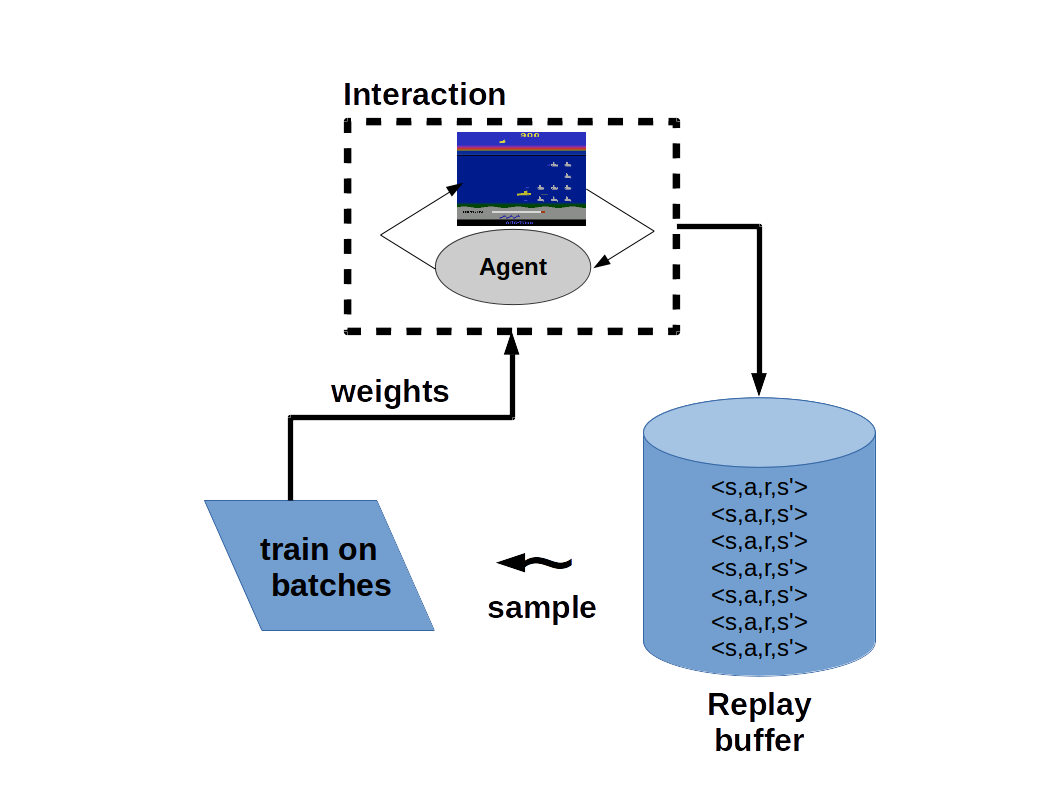

#### Обучение с experience replay
1. Сыграть шаг игры, отсэмплировать `<s,a,r,s'>`.
2. Обновить q-values на основе `<s,a,r,s'>`.
3. Записать `<s,a,r,s'>` в буфер.
 3. Если буфер полный, то удалить ранние данные.
4. Сэмплировать K таких переходов из данного буфера и обновить q-values на их основе.

#### Интерфейс довольно простой:
* `exp_replay.add(obs, act, rw, next_obs, done)`  &mdash; сохраняет кортеж (s,a,r,s',done) в буфер
* `exp_replay.sample(batch_size)` &mdash; возвращает наблюдения, действия, награды, следующие наблюдения и is_done для `batch_size` случайных сэмплов.
* `len(exp_replay)` &mdash; возвращает количество элементов, хранящихся в буфере на данный момент.


Для применения такого обучения требуется, во-первых, реализация структуры памяти, которая будет работать как буфер.

<span style="color: green"> __(0.6 балла)__ </span>

In [43]:
class ReplayBuffer(object):
    def __init__(self, size, alpha=0.6):
        """
        Создаёт буфер реплеев.
        Параметры
        ----------
        size: int
            Максимальное количество хранящихся единовременно переходов. При переполнении буфера старые
            записи удаляются.

        Замечание: для данного задания можно выбрать любую структуру данных.
              Если Вам достаточно простого решения, то можно просто хранить список кортежей (s, a, r, s')
              в self._storage. Однако, можно найти более быстрые и/или эффективные по памяти способы
              реализации самого хранения переходов.
        """
        #self._storage = []    ???? подумать
        self._storage = deque(maxlen=size)
        self._maxsize = size
        self._priorities = deque(maxlen=size)
        self._alpha = alpha

    def __len__(self):
        return len(self._storage)

    def add_random(self, obs_t, action, reward, obs_tp1, done):
        '''
        Убедитесь, что _storage не превзойдёт по размерам _maxsize.
        Убедитесь, что FIFO правило выполняется: старейшие прецеденты должны удаляться раньше всех.
        '''
        data = (obs_t, action, reward, obs_tp1, done)
        self._storage.append(data)

    def sample_random(self, batch_size):
        """Сэмплирование батча переходов.
        Параметры
        ----------
        batch_size: int
            Сколько переходов сэмплировать.
        Возвращает
        -------
        obs_batch: np.array
            батч наблюдений (состояний)
        act_batch: np.array
            батч действий, выполненных на основе obs_batch
        rew_batch: np.array
            награды, полученные в качестве результата выполнения act_batch
        next_obs_batch: np.array
            следующие наблюдения (состояния), полученные после выполнения act_batch
        done_mask: np.array
            done_mask[i] = 1, если выполнение act_batch[i] повлекло
            окончание эпизода и 0 иначе.
        """
        #storage = self._storage

        #< случайно сгенерировать batch_size индексов сэмплов в буфере >
        idxes = np.random.choice(len(self._storage), batch_size)

        # собрать <s,a,r,s',done> для каждого индекса
        sample = list(zip(*(self._storage[i] for i in idxes)))

        # < states > , < actions >, < rewards >,  < next_states >, < is_done >
        return (np.array(sample[0]), np.array(sample[1]), np.array(sample[2]), np.array(sample[3]), np.array(sample[4]))

In [44]:
exp_replay = ReplayBuffer(10)

for _ in range(30):
    exp_replay.add_random(env.reset()[0], env.action_space.sample(), 1.0, env.reset()[0], done=False)

obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch = exp_replay.sample_random(5)

assert len(exp_replay) == 10, "размер буфера должен быть равен 10, потому что это максимальная вместимость"

<span style="color: green"> __(0.6 балла)__ </span>

In [45]:
def play_and_record(initial_state, agent, env, exp_replay, n_steps=1):
    """
    Сыграть в игру n_steps шагов, записать каждый (s,a,r,s', done) в exp_replay буфер.
    Как только игра заканчивается, добавляется запись с done=True и среда env перезапускается.
    Гарантируетcя, что env находится в состоянии done=False после работы функции.

    ПРОСЬБА НЕ ПЕРЕЗАПУСКАТЬ ENV, ПОКА ОНА НЕ В СОСТОЯНИИ "DONE"

    :возвращает: сумму наград по времени и состояние, в котором среда оказалась
    """
    s = initial_state
    sum_rewards = 0

    # Сыграть в игру n_steps шагов согласно инструкциям выше
    for _ in range(n_steps):
        qvalues = agent.get_qvalues([s])
        a = agent.sample_actions(qvalues)[0] # берем действие через политику

        new_s, r, done, _, _ = env.step(a) # делаем шаг в среде
        sum_rewards += r

        exp_replay.add_random(s, a, r, new_s, done) # записываем переход в буфер

        if done:
            s, _ = env.reset()
        else:
            s = new_s

    return sum_rewards, s

Для TwinDQN функция *play_and_record* будет иметь немного другой вид. Записывайте результат любой из двух моделей

<span style="color: green"> __(0.6 балла)__ </span>

In [46]:
def play_and_record_twin(initial_state, agent, env, exp_replay, n_steps=1, regime='random'):
    """
    Сыграть в игру n_steps шагов, записать каждый (s,a,r,s', done) в exp_replay буфер.
    Как только игра заканчивается, добавляется запись с done=True и среда env перезапускается.
    Гарантируетcя, что env находится в состоянии done=False после работы функции.

    ПРОСЬБА НЕ ПЕРЕЗАПУСКАТЬ ENV, ПОКА ОНА НЕ В СОСТОЯНИИ "DONE"

    :возвращает: сумму наград по времени и состояние, в котором среда оказалась
    """
    s = initial_state
    sum_rewards = 0

    # Сыграть в игру n_steps шагов согласно инструкциям выше
    for _ in range(n_steps):
        q1, q2 = agent.get_qvalues([s])
        
        if regime == 'random':
            q_for_action = q1 if np.random.rand() < 0.5 else q2
        elif regime == 'first':
            q_for_action = q1
        else:
            q_for_action = q2

        a = agent.sample_actions(q_for_action)[0]

        new_s, r, done, _, _ = env.step(a)
        sum_rewards += r
        
        exp_replay.add_random(s, a, r, new_s, done)

        if done:
            s, _ = env.reset()
        else:
            s = new_s

    return sum_rewards, s

In [47]:
# Протестируйте Ваш код.
exp_replay = ReplayBuffer(2000)

state, _ = env.reset()
play_and_record(state, agent, env, exp_replay, n_steps=1000)

# если вы используете собственный experience replay буфер, то некоторые из тестов, возможно, потребуется
# скорректировать.
# Убедитесь в том, что Вы знаете, что Ваш код делает
assert len(exp_replay) == 1000,\
    "play_and_record должна добавить ровно 1000 шагов, но вместо этого добавила %i" % len(exp_replay)

is_dones = list(zip(*exp_replay._storage))[-1]

assert 0 < np.mean(is_dones) < 0.1,\
"Убедитесь, что Вы перезапускаете игру, как только она 'done', и корректно записываете is_done в буфер."\
"Получена %f доля is_done за %i шагов. [Если думаете, что Вам не повезло, то просто перезапустите тест.]" % (
                                        np.mean(is_dones), len(exp_replay))

for _ in range(100):
    obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch = exp_replay.sample_random(10)
    assert obs_batch.shape == next_obs_batch.shape == (10,) + state_shape
    assert act_batch.shape == (10,),\
        "батч действий должен иметь размер (10,), но имееет %s" % str(act_batch.shape)
    assert reward_batch.shape == (10,),\
        "батч наград должен иметь размер (10,), но имееет %s" % str(reward_batch.shape)
    assert is_done_batch.shape == (10,),\
        "батч is_done должен иметь размер (10,), но имееет %s" % str(is_done_batch.shape)
    assert [int(i) in (0, 1) for i in is_dones],\
        "is_done должен быть строго True или False"
    assert [0 <= a < n_actions for a in act_batch],\
        "действия должны быть в промежутке [0, n_actions]"

print("Отлично справились!")

Отлично справились!


# Целевые сети

Также будет реализована так называемая "целевая сеть" &mdash; копия весов нейронной сети агента, используемая для оценки целевого значения Q-функции:

Сама по себе сеть представляет собой точную копию сети агента, но её параметры не обучаются. Наоборот, они берутся из обучаемой сети агента раз в несколько итераций цикла обучения.

$$ Q_{reference}(s,a) = r + \gamma \cdot \max _{a'} Q_{target}(s',a') $$

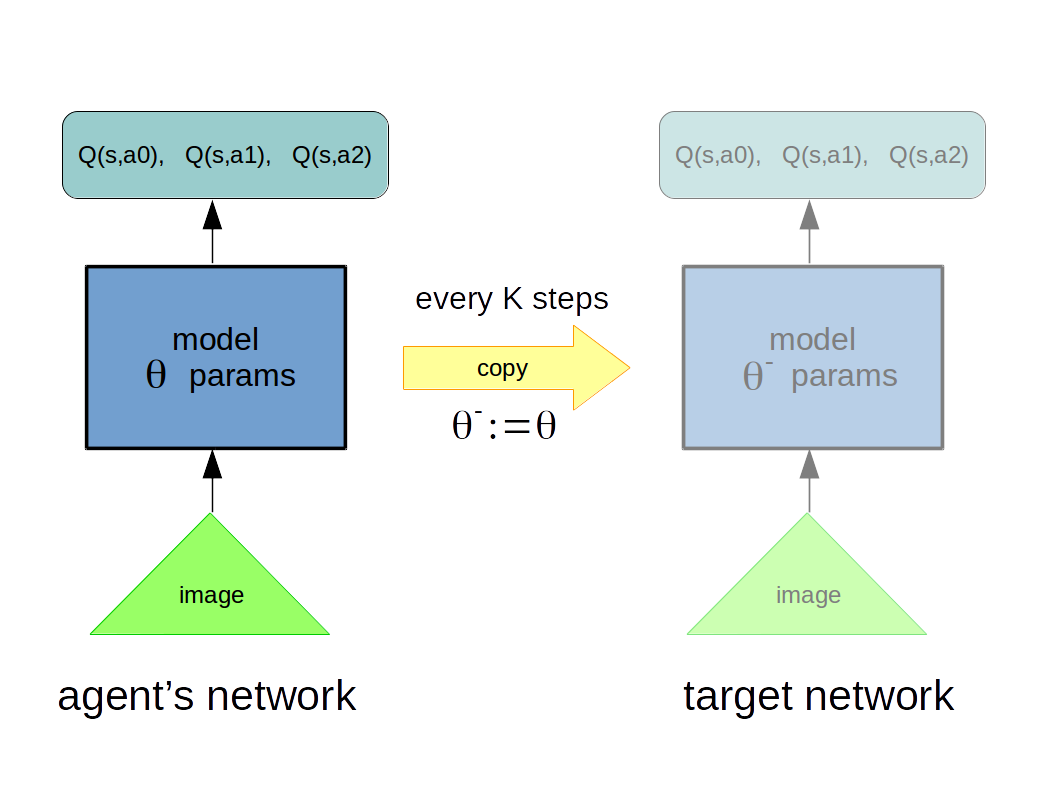

Реализуем функции потерь для модификаций DQN

<span style="color: green"> __(1 балл)__ </span>

In [48]:
def compute_td_loss(states, actions, rewards, next_states, is_done,
                    agent, target_network,
                    gamma=0.99, 
                    check_shapes=False,
                    device=device):
    """
    Вычислите td функцию потерь, используя только операции PyTorch. Используйте формулы выше.
    """
    states = torch.tensor(states, device=device, dtype=torch.float)           # размер: [batch_size, *state_shape]
    actions = torch.tensor(actions, device=device, dtype=torch.long)          # размер: [batch_size]
    rewards = torch.tensor(rewards, device=device, dtype=torch.float)         # размер: [batch_size]
    next_states = torch.tensor(next_states, device=device, dtype=torch.float) # размер: [batch_size, *state_shape]
    is_done = torch.tensor(is_done.astype('float32'), device=device, dtype=torch.float)  # размер: [batch_size]
    is_not_done = 1 - is_done

    # получить q-values для всех действий в текущих состояниях
    predicted_qvalues =  agent(states) # текущая оценка 

    # вычислить q-values для всех действий в следующих состояниях
    with torch.no_grad(): predicted_next_qvalues = target_network(next_states)

    # выбрать q-values для соответствующих выбранных действий
    predicted_qvalues_for_actions = predicted_qvalues[torch.arange(states.shape[0]), actions]

    # вычислить V*(next_states), используя предсказанные следующие q-values
    next_state_values, _ = torch.max(predicted_next_qvalues, dim=1)

    assert next_state_values.dim() == 1 and next_state_values.shape[0] == states.shape[0],\
        "нужно предсказывать одно действие для состояния"

    # вычислить "target q-values" для функции потерь - то, что внутри квадратных скобок в формуле выше.
    # в последнем состоянии использовать упрощённую формулу: Q(s,a) = r(s,a) так как s' не существует
    # Вы можете умножить следующие состояния на is_not_done для достижения этого.
    target_qvalues_for_actions = rewards + gamma * next_state_values * is_not_done

    assert predicted_qvalues_for_actions.shape == target_qvalues_for_actions.shape

    # среднеквадратическая функция потерь для минимизации
    loss = torch.mean((predicted_qvalues_for_actions - target_qvalues_for_actions) ** 2)

    if check_shapes:
        assert predicted_next_qvalues.data.dim() == 2,\
            "убедитесь, что Вы предсказали все q-values для всех действий в следующих состояниях"
        assert next_state_values.data.dim() == 1,\
            "убедитесь, что Вы вычислили V(s') как максимум по оси действий в тензоре, а не по всем осям"
        assert target_qvalues_for_actions.data.dim() == 1,\
            "что-то не то с целевыми q-values, они должны быть вектором"

    return loss

<span style="color: green"> __(1 балл)__ </span>

In [49]:
def compute_td_loss_twin(states, actions, rewards, next_states, is_done,
                    agent, target_network,
                    gamma=0.99,
                    check_shapes=False,
                    device=device):
    
    states = torch.tensor(states, device=device, dtype=torch.float)
    actions = torch.tensor(actions, device=device, dtype=torch.long)
    rewards = torch.tensor(rewards, device=device, dtype=torch.float)
    next_states = torch.tensor(next_states, device=device, dtype=torch.float)
    is_done = torch.tensor(is_done.astype('float32'), device=device, dtype=torch.float)
    is_not_done = 1 - is_done

    # ------- Q(s, a) -------
    q1, q2 = agent(states)
    q1_for_actions = q1[torch.arange(states.shape[0]), actions]
    q2_for_actions = q2[torch.arange(states.shape[0]), actions]

    # ------- Q(s', a') -------
    with torch.no_grad():
        q1_next, q2_next = target_network(next_states)
        next_state_values_1, _ = torch.max(q1_next, dim=1)
        next_state_values_2, _ = torch.max(q2_next, dim=1)

    # ------- Targets -------
    target_qvalues_1 = rewards + gamma * next_state_values_1 * is_not_done
    target_qvalues_2 = rewards + gamma * next_state_values_2 * is_not_done

    # Сумма среднеквадратичных квадратичных потерь для двух сетей
    loss = torch.mean((q1_for_actions - target_qvalues_1) ** 2) + \
        torch.mean((q2_for_actions - target_qvalues_2) ** 2)
    
    #if check_shapes:
        #assert q1_next.data.dim() == 2
        #assert next_state_values.data.dim() == 1
        #assert target_qvalues_for_actions.data.dim() == 1

    return loss


In [50]:
target_network = DQNAgent(agent.state_shape, agent.n_actions, epsilon=0.5).to(device)
target_network.load_state_dict(agent.state_dict())

obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch = exp_replay.sample_random(10)

loss = compute_td_loss(obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch,
                       agent, target_network,
                       gamma=0.99, check_shapes=True)
loss.backward()

assert loss.requires_grad and tuple(loss.data.size()) == (),\
    "Вы должны вернуть скаляр значения функции потерь - среднее по батчу."
assert np.any(next(agent.parameters()).grad.data.cpu().numpy() != 0),\
    "Функция потерь должна быть дифференцируема относительно весов сети."
assert np.all(next(target_network.parameters()).grad is None),\
    "Целевая сеть не должна быть дифференцируемой."

In [51]:
target_network = DuelingDQNAgent(agent_dueling.state_shape, agent_dueling.n_actions, epsilon=0.5).to(device)
target_network.load_state_dict(agent_dueling.state_dict())

obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch = exp_replay.sample_random(10)

loss = compute_td_loss(obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch,
                       agent_dueling, target_network,
                       gamma=0.99, check_shapes=True)
loss.backward()

assert loss.requires_grad and tuple(loss.data.size()) == (),\
    "Вы должны вернуть скаляр значения функции потерь - среднее по батчу."
assert np.any(next(agent_dueling.parameters()).grad.data.cpu().numpy() != 0),\
    "Функция потерь должна быть дифференцируема относительно весов сети."
assert np.all(next(target_network.parameters()).grad is None),\
    "Целевая сеть не должна быть дифференцируемой."

In [52]:
target_network = TwinDQNAgent(agent_twin.state_shape, agent_twin.n_actions, epsilon=0.5).to(device)
target_network.load_state_dict(agent_twin.state_dict())

obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch = exp_replay.sample_random(10)

loss = compute_td_loss_twin(obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch,
                       agent_twin, target_network,
                       gamma=0.99, check_shapes=True)
loss.backward()

assert loss.requires_grad and tuple(loss.data.size()) == (),\
    "Вы должны вернуть скаляр значения функции потерь - среднее по батчу."
assert np.any(next(agent_twin.parameters()).grad.data.cpu().numpy() != 0),\
    "Функция потерь должна быть дифференцируема относительно весов сети."
assert np.all(next(target_network.parameters()).grad is None),\
    "Целевая сеть не должна быть дифференцируемой."

# Обучение

In [53]:
seed = 617
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [54]:
env = make_env()
state_dim = env.observation_space.shape
n_actions = env.action_space.n

**DQN**

In [55]:
state, _ = env.reset()
agent = DQNAgent(state_dim, n_actions, epsilon=1).to(device)
target_network = DQNAgent(state_dim, n_actions, epsilon=1).to(device)
target_network.load_state_dict(agent.state_dict())

mean_rw_history = []
td_loss_history = []
grad_norm_history = []
initial_state_v_history = []

In [56]:
exp_replay = ReplayBuffer(10**4)
for i in range(100):
    if not utils.is_enough_ram(min_available_gb=0.1):
        print("""
            Меньше, чем 100 Mb RAM, доступно.
            Убедитесь, что размер буфера не слишком большой.
            Также проверьте, может, другие процессы потребляют сильно много RAM.
            """
             )
        break
    play_and_record(state, agent, env, exp_replay, n_steps=10**2)
    if len(exp_replay) == 10**4:
        break
print(len(exp_replay))

10000


In [57]:
timesteps_per_epoch = 30
batch_size = 42
total_steps = 25000
decay_steps = 8000

opt = torch.optim.Adam(agent.parameters(), lr=5e-4)
opt.zero_grad()

init_epsilon = 1
final_epsilon = 0.1

loss_freq = 20
refresh_target_network_freq = 200
eval_freq = 1000

max_grad_norm = 1
max_grad_norm = 10 #5000
gamma = 0.99

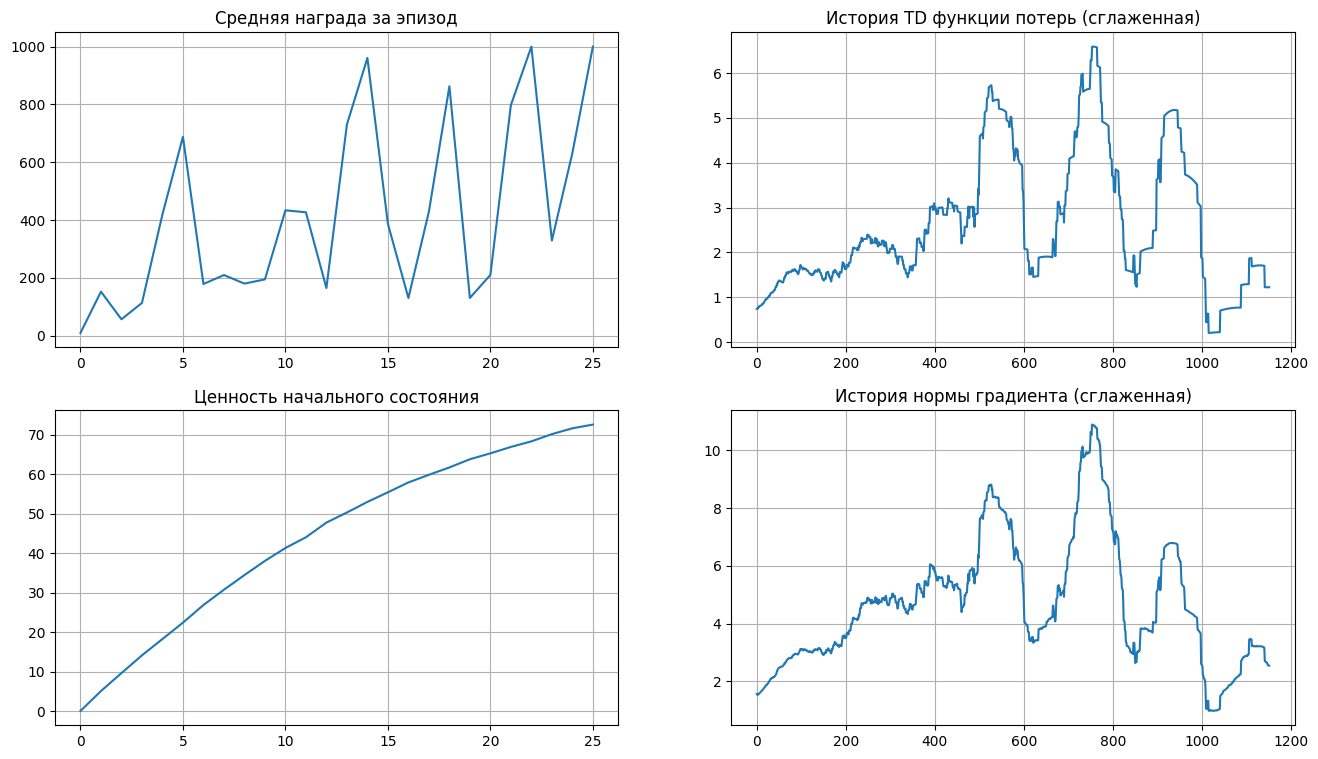

100%|██████████| 25001/25001 [06:00<00:00, 69.32it/s]


In [58]:
best_eval = -np.inf
best_state = None

state, _ = env.reset()
for step in trange(total_steps + 1):
    if not utils.is_enough_ram():
        print('Меньше, чем 100 Mb RAM, доступно, заморозка процедуры обучения')
        print('убедитесь, что всё в порядке и пошлите сигнал KeyboardInterrupt для продолжения')
        try:
            while True:
                pass
        except KeyboardInterrupt:
            pass

    agent.epsilon = utils.linear_decay(init_epsilon, final_epsilon, step, decay_steps)

    # игра
    _, state = play_and_record(state, agent, env, exp_replay, timesteps_per_epoch)

    # обучение
    obs_batch, act_batch, rew_batch, next_obs_batch, done_mask = exp_replay.sample_random(batch_size)

    loss = compute_td_loss(obs_batch, act_batch, rew_batch, next_obs_batch, done_mask, agent, target_network, gamma)

    loss.backward()
    grad_norm = nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm).item()
    opt.step()
    opt.zero_grad()

    if step % loss_freq == 0:
        td_loss_history.append(loss.data.cpu().item())
        grad_norm_history.append(grad_norm)

    if step % refresh_target_network_freq == 0:
        # Загрузка весов агента в target_network
        target_network.load_state_dict(agent.state_dict())

    if step % eval_freq == 0:
        # Оценка агента
        eval_rw = evaluate(make_env(), agent, n_games=5, greedy=True, t_max=1000)
        mean_rw_history.append(eval_rw)

        initial_state_q_values = agent.get_qvalues([make_env().reset()[0]])
        initial_state_v_history.append(np.max(initial_state_q_values))

        if eval_rw > best_eval:
            best_eval = eval_rw
            best_state = {k: v.detach().cpu().clone() for k, v in agent.state_dict().items()}
            
        print(f"step={step} buffer={len(exp_replay)} eps={agent.epsilon:.4f} eval={eval_rw:.2f} best={best_eval:.2f}")

        print("размер буфера = %i, epsilon = %.5f" % (len(exp_replay), agent.epsilon))

        plt.figure(figsize=[16, 9])
        plt.subplot(2, 2, 1)
        plt.title("Средняя награда за эпизод")
        plt.plot(mean_rw_history)
        plt.grid()

        assert not np.isnan(td_loss_history[-1])
        plt.subplot(2, 2, 2)
        plt.title("История TD функции потерь (сглаженная)")
        plt.plot(utils.smoothen(td_loss_history))
        plt.grid()

        plt.subplot(2, 2, 3)
        plt.title("Ценность начального состояния")
        plt.plot(initial_state_v_history)
        plt.grid()

        plt.subplot(2, 2, 4)
        plt.title("История нормы градиента (сглаженная)")
        plt.plot(utils.smoothen(grad_norm_history))
        plt.grid()

        clear_output(True)
        plt.show()

In [ ]:
if best_state is not None:
    agent.load_state_dict(best_state)
    print(f"Loaded best checkpoint with eval={best_eval:.2f}")

In [59]:
final_score = evaluate(make_env(), agent, n_games=30, greedy=True, t_max=1000)
print('финальный счёт:', final_score)
assert final_score > 500, 'недостаточно хорошо для DQN'
print('Отлично справились')

финальный счёт: 1000.0
Отлично справились


Теперь, когда сеть обучилась, запишем видео

In [60]:
# запись эпизодов
with RecordVideo(
    env=gym.make(ENV_NAME, render_mode="rgb_array"),
    video_folder="./videos_DQN/False",
    episode_trigger=lambda episode_number: True
) as env_monitor:
    sessions = [evaluate(env_monitor, agent, greedy=False, t_max=1000) for _ in range(5)]

c:\Users\Администратор\AppData\Local\Programs\Python\Python313\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [61]:
video_paths = sorted([s for s in Path('videos_DQN', 'False').iterdir() if s.suffix == '.mp4'])
video_path = video_paths[-1]
data_url = str(video_path)

HTML("""
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(data_url))

In [62]:
# запись эпизодов
with RecordVideo(
    env=gym.make(ENV_NAME, render_mode="rgb_array"),
    video_folder="./videos_DQN/True",
    episode_trigger=lambda episode_number: True
) as env_monitor:
    sessions = [evaluate(env_monitor, agent, greedy=True, t_max=1000) for _ in range(5)]

In [63]:
video_paths = sorted([s for s in Path('videos_DQN', 'True').iterdir() if s.suffix == '.mp4'])
video_path = video_paths[-1]
data_url = str(video_path)

HTML("""
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(data_url))

**TwinDQN**

In [76]:
state, _ = env.reset()

agent = TwinDQNAgent(state_dim, n_actions, epsilon=1).to(device)
target_network = TwinDQNAgent(state_dim, n_actions, epsilon=1).to(device)
target_network.load_state_dict(agent.state_dict())

<All keys matched successfully>

In [77]:
exp_replay = ReplayBuffer(10**4)
for i in range(100):
    if not utils.is_enough_ram(min_available_gb=0.1):
        print("""
            Меньше, чем 100 Mb RAM, доступно.
            Убедитесь, что размер буфера не слишком большой.
            Также проверьте, может, другие процессы потребляют сильно много RAM.
            """
             )
        break
    play_and_record_twin(state, agent, env, exp_replay, n_steps=10**2, regime='random')
    if len(exp_replay) == 10**4:
        break
print(len(exp_replay))

10000


In [78]:
timesteps_per_epoch = 30
batch_size = 42
total_steps = 25000
decay_steps = 8000

opt = torch.optim.Adam(agent.parameters(), lr=5e-4)
opt.zero_grad()

init_epsilon = 1
final_epsilon = 0.1

loss_freq = 20
refresh_target_network_freq = 100
eval_freq = 1000

max_grad_norm = 1
max_grad_norm = 10 #5000
gamma = 0.99

In [79]:
mean_rw_history = []
td_loss_history = []
grad_norm_history = []
initial_state_v_history = []

best_eval_twin = -np.inf
best_state_twin = None

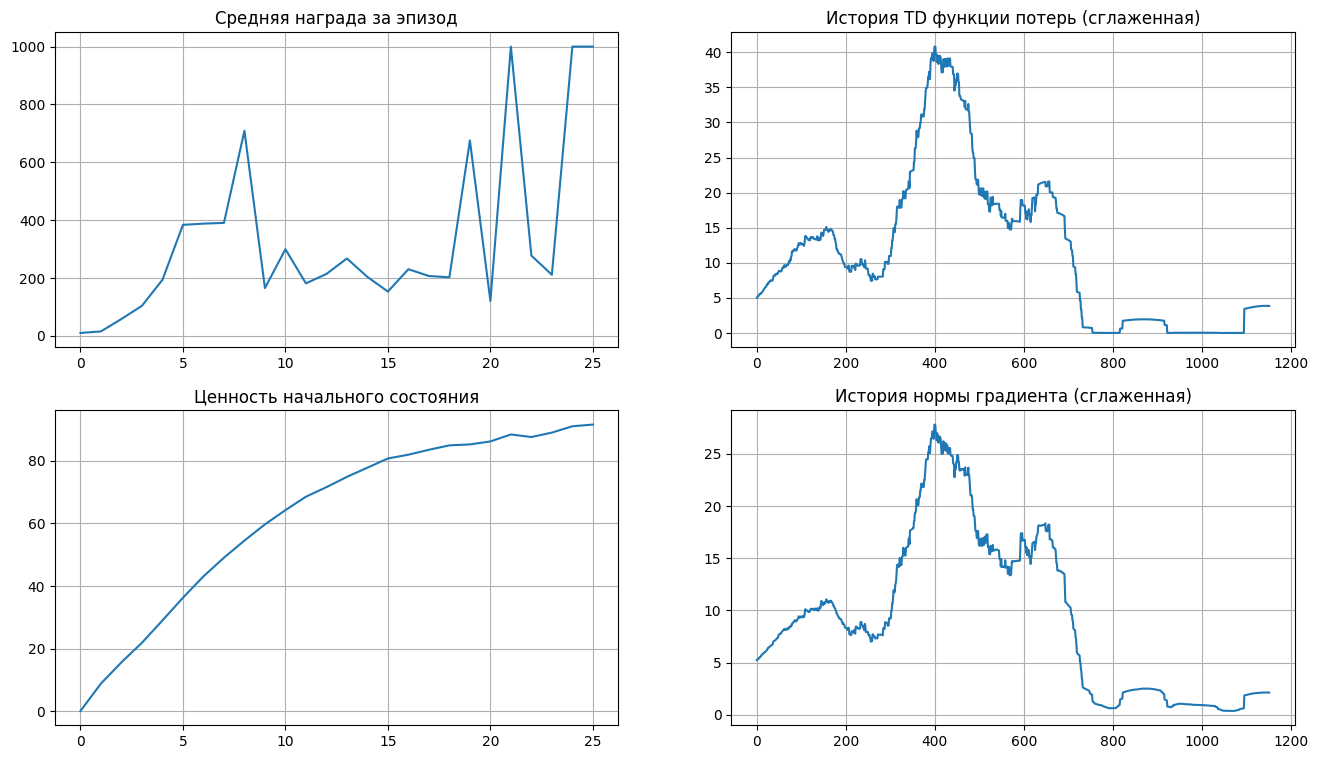

100%|██████████| 25001/25001 [09:06<00:00, 45.77it/s]


In [80]:
state, _ = env.reset()
for step in trange(total_steps + 1):
    if not utils.is_enough_ram():
        print('Меньше, чем 100 Mb RAM, доступно, заморозка процедуры обучения')
        print('убедитесь, что всё в порядке и пошлите сигнал KeyboardInterrupt для продолжения')
        try:
            while True:
                pass
        except KeyboardInterrupt:
            pass

    agent.epsilon = utils.linear_decay(init_epsilon, final_epsilon, step, decay_steps)

    # игра
    _, state = play_and_record_twin(state, agent, env, exp_replay, timesteps_per_epoch)

    # обучение
    obs_batch, act_batch, rew_batch, next_obs_batch, done_mask = exp_replay.sample_random(batch_size)

    loss = compute_td_loss_twin(obs_batch, act_batch, rew_batch, next_obs_batch, done_mask, agent, target_network, gamma)

    loss.backward()
    grad_norm = nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm).item()
    opt.step()
    opt.zero_grad()

    if step % loss_freq == 0:
        td_loss_history.append(loss.data.cpu().item())
        grad_norm_history.append(grad_norm)

    if step % refresh_target_network_freq == 0:
        # Загрузка весов агента в target_network
        target_network.load_state_dict(agent.state_dict())

    if step % eval_freq == 0:
        # Оценка агента
        eval_rw = evaluate_twin(make_env(), agent, n_games=5, greedy=True, t_max=1000)
        mean_rw_history.append(eval_rw)

        initial_state_q_values = agent.get_qvalues([make_env().reset()[0]])[0]  # берем q1
        initial_state_v_history.append(np.max(initial_state_q_values))

        if eval_rw > best_eval_twin:
            best_eval_twin = eval_rw
            best_state_twin = {k: v.detach().cpu().clone() for k, v in agent.state_dict().items()}

        print(f"step={step} buffer={len(exp_replay)} eps={agent.epsilon:.4f} eval={eval_rw:.2f} best={best_eval_twin:.2f}")

        print("размер буфера = %i, epsilon = %.5f" % (len(exp_replay), agent.epsilon))

        plt.figure(figsize=[16, 9])
        plt.subplot(2, 2, 1)
        plt.title("Средняя награда за эпизод")
        plt.plot(mean_rw_history)
        plt.grid()

        assert not np.isnan(td_loss_history[-1])
        plt.subplot(2, 2, 2)
        plt.title("История TD функции потерь (сглаженная)")
        plt.plot(utils.smoothen(td_loss_history))
        plt.grid()

        plt.subplot(2, 2, 3)
        plt.title("Ценность начального состояния")
        plt.plot(initial_state_v_history)
        plt.grid()

        plt.subplot(2, 2, 4)
        plt.title("История нормы градиента (сглаженная)")
        plt.plot(utils.smoothen(grad_norm_history))
        plt.grid()

        clear_output(True)
        plt.show()

In [83]:
if best_state_twin is not None:
    agent.load_state_dict(best_state_twin)
    print(f"Loaded best Twin checkpoint: {best_eval_twin:.2f}")

Loaded best Twin checkpoint: 1000.00


In [85]:
final_score = evaluate_twin(make_env(), agent, n_games=30, greedy=True, t_max=1000)
print('финальный счёт:', final_score)
assert final_score > 500, 'недостаточно хорошо для DQN'
print('Отлично справились')

финальный счёт: 1000.0
Отлично справились


In [90]:
# запись эпизодов
with RecordVideo(
    env=gym.make(ENV_NAME, render_mode="rgb_array"),
    video_folder="./videos_Twin/False",
    episode_trigger=lambda episode_number: True
) as env_monitor:
    sessions = [evaluate_twin(env_monitor, agent, greedy=False, t_max=1000) for _ in range(5)]

c:\Users\Администратор\AppData\Local\Programs\Python\Python313\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\dev\rl_mipt_course\tasks\task3\videos_Twin\False folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [91]:
video_paths = sorted([s for s in Path('videos_Twin', 'False').iterdir() if s.suffix == '.mp4'])
video_path = video_paths[-1]
data_url = str(video_path)

HTML("""
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(data_url))

In [92]:
# запись эпизодов
with RecordVideo(
    env=gym.make(ENV_NAME, render_mode="rgb_array"),
    video_folder="./videos_Twin/True",
    episode_trigger=lambda episode_number: True
) as env_monitor:
    sessions = [evaluate_twin(env_monitor, agent, greedy=True, t_max=1000) for _ in range(5)]

c:\Users\Администратор\AppData\Local\Programs\Python\Python313\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\dev\rl_mipt_course\tasks\task3\videos_Twin\True folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [93]:
video_paths = sorted([s for s in Path('videos_Twin', 'True').iterdir() if s.suffix == '.mp4'])
video_path = video_paths[-1]
data_url = str(video_path)

HTML("""
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(data_url))

**DuelingDQN**

In [97]:
state, _ = env.reset()

agent = DuelingDQNAgent(state_dim, n_actions, epsilon=1).to(device)
target_network = DuelingDQNAgent(state_dim, n_actions, epsilon=1).to(device)
target_network.load_state_dict(agent.state_dict())

<All keys matched successfully>

In [98]:
exp_replay = ReplayBuffer(10**4)
for i in range(100):
    if not utils.is_enough_ram(min_available_gb=0.1):
        print("""
            Меньше, чем 100 Mb RAM, доступно.
            Убедитесь, что размер буфера не слишком большой.
            Также проверьте, может, другие процессы потребляют сильно много RAM.
            """
             )
        break
    play_and_record(state, agent, env, exp_replay, n_steps=10**2)
    if len(exp_replay) == 10**4:
        break
print(len(exp_replay))

10000


In [99]:
timesteps_per_epoch = 30
batch_size = 42
total_steps = 25000
decay_steps = 8000

opt = torch.optim.Adam(agent.parameters(), lr=5e-4)
opt.zero_grad()

init_epsilon = 1
final_epsilon = 0.1

loss_freq = 20
refresh_target_network_freq = 200
eval_freq = 1000

max_grad_norm = 1
max_grad_norm = 10
gamma = 0.99

In [100]:
mean_rw_history = []
td_loss_history = []
grad_norm_history = []
initial_state_v_history = []

best_eval_dueling = -np.inf
best_state_dueling = None

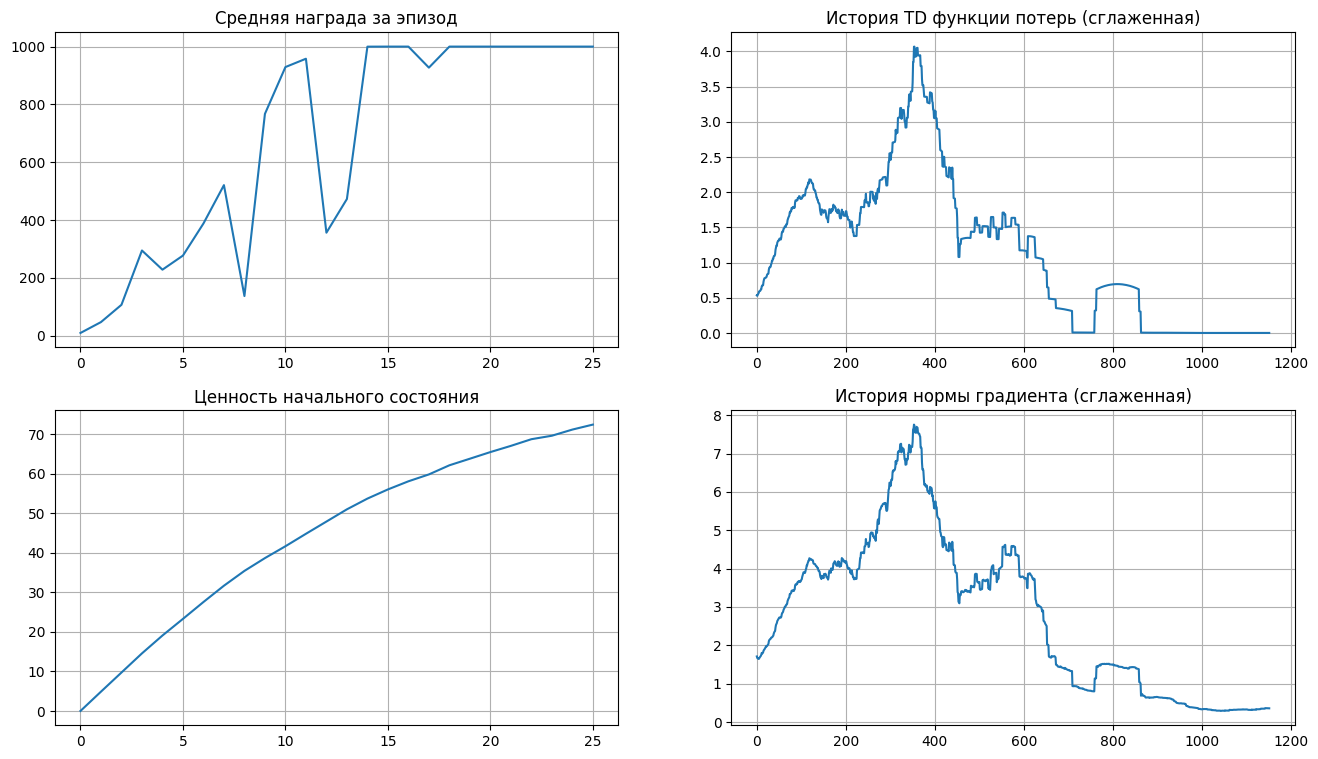

100%|██████████| 25001/25001 [07:28<00:00, 55.80it/s]


In [101]:
state, _ = env.reset()
for step in trange(total_steps + 1):
    if not utils.is_enough_ram():
        print('Меньше, чем 100 Mb RAM, доступно, заморозка процедуры обучения')
        print('убедитесь, что всё в порядке и пошлите сигнал KeyboardInterrupt для продолжения')
        try:
            while True:
                pass
        except KeyboardInterrupt:
            pass

    agent.epsilon = utils.linear_decay(init_epsilon, final_epsilon, step, decay_steps)

    # игра
    _, state = play_and_record(state, agent, env, exp_replay, timesteps_per_epoch)

    # обучение
    obs_batch, act_batch, rew_batch, next_obs_batch, done_mask = exp_replay.sample_random(batch_size)

    loss = compute_td_loss(obs_batch, act_batch, rew_batch, next_obs_batch, done_mask, agent, target_network, gamma)

    loss.backward()
    grad_norm = nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm).item()
    opt.step()
    opt.zero_grad()

    if step % loss_freq == 0:
        td_loss_history.append(loss.data.cpu().item())
        grad_norm_history.append(grad_norm)

    if step % refresh_target_network_freq == 0:
        # Загрузка весов агента в target_network
        target_network.load_state_dict(agent.state_dict())

    if step % eval_freq == 0:
        # Оценка агента
        eval_rw = evaluate(make_env(), agent, n_games=5, greedy=True, t_max=1000)
        mean_rw_history.append(eval_rw)

        initial_state_q_values = agent.get_qvalues([make_env().reset()[0]])
        initial_state_v_history.append(np.max(initial_state_q_values))

        if eval_rw > best_eval_dueling:
            best_eval_dueling = eval_rw
            best_state_dueling = {k: v.detach().cpu().clone() for k, v in agent.state_dict().items()}

        print(f"step={step} buffer={len(exp_replay)} eps={agent.epsilon:.4f} eval={eval_rw:.2f} best={best_eval_dueling:.2f}")

        print("размер буфера = %i, epsilon = %.5f" % (len(exp_replay), agent.epsilon))

        plt.figure(figsize=[16, 9])
        plt.subplot(2, 2, 1)
        plt.title("Средняя награда за эпизод")
        plt.plot(mean_rw_history)
        plt.grid()

        assert not np.isnan(td_loss_history[-1])
        plt.subplot(2, 2, 2)
        plt.title("История TD функции потерь (сглаженная)")
        plt.plot(utils.smoothen(td_loss_history))
        plt.grid()

        plt.subplot(2, 2, 3)
        plt.title("Ценность начального состояния")
        plt.plot(initial_state_v_history)
        plt.grid()

        plt.subplot(2, 2, 4)
        plt.title("История нормы градиента (сглаженная)")
        plt.plot(utils.smoothen(grad_norm_history))
        plt.grid()

        clear_output(True)
        plt.show()

In [102]:
if best_state_dueling is not None:
    agent.load_state_dict(best_state_dueling)
    print(f"Loaded best Dueling checkpoint: {best_eval_dueling:.2f}")

Loaded best Dueling checkpoint: 1000.00


In [103]:
final_score = evaluate(make_env(), agent, n_games=30, greedy=True, t_max=1000)
print('финальный счёт:', final_score)
assert final_score > 500, 'недостаточно хорошо для DQN'
print('Отлично справились')

финальный счёт: 919.3666666666667
Отлично справились


In [105]:
# запись эпизодов
with RecordVideo(
    env=gym.make(ENV_NAME, render_mode="rgb_array"),
    video_folder="./videos_Dueling/False",
    episode_trigger=lambda episode_number: True
) as env_monitor:
    sessions = [evaluate(env_monitor, agent, greedy=False, t_max=1000) for _ in range(5)]

In [106]:
video_paths = sorted([s for s in Path('videos_Dueling', 'False').iterdir() if s.suffix == '.mp4'])
video_path = video_paths[-1]
data_url = str(video_path)

HTML("""
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(data_url))

In [107]:
# запись эпизодов
with RecordVideo(
    env=gym.make(ENV_NAME, render_mode="rgb_array"),
    video_folder="./videos_Dueling/True",
    episode_trigger=lambda episode_number: True
) as env_monitor:
    sessions = [evaluate(env_monitor, agent, greedy=True, t_max=1000) for _ in range(5)]

In [108]:
video_paths = sorted([s for s in Path('videos_Dueling', 'True').iterdir() if s.suffix == '.mp4'])
video_path = video_paths[-1]
data_url = str(video_path)

HTML("""
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(data_url))

# DQN with multiple steps

Выше мы использовали одношаговую стратегию семплирования в DQN. Такой подход страдает из-за проблемы отложенного сигнала  и сопряжённой с ней в контексте нейросетевой аппроксимации проблемы накапливающейся ошибки. Эвристика для борьбы с этой проблемой - распространять награду за одну итерацию на несколько шагов вперед. Грубо говоря, в буфере переходов будем хранить
\begin{equation*}
  T=\left(s,a,\sum_{n=0}^{N-1}\gamma^nr^{(n)},s^{(N)},done\right).
\end{equation*}

Для этого нам придется переписать *ReplayBuffer* и *play_and_record*. Использовать будем обычный DQNAgent.

<span style="color: green"> __(2 балла)__ </span>

In [ ]:
class ReplayBuffer_multistep(object):
    def __init__(self, size, gamma=0.99, n_steps=5):
        self._storage = deque(maxlen=size)
        self._maxsize = size
        self._gamma = gamma
        self._n_steps = n_steps
        self._n_step_buffer = deque(maxlen=n_steps)

    def __len__(self):
        return len(self._storage)

    def add_multi_step(self, obs_t, action, reward, obs_tp1, done):
        """
        Добавляет новый переход и, если накоплено достаточно шагов, сохраняет N-step переход.
        """
        self._n_step_buffer.append((obs_t, action, reward, obs_tp1, done))

        # пока не накопили n шагов, нечего добавлять
        if len(self._n_step_buffer) < self._n_steps:
            if done:
                self._n_step_buffer.clear()
            return

        # стартовые st и at
        s_t, a_t = self._n_step_buffer[0][0], self._n_step_buffer[0][1]

        # n-step дисконтированная награда
        R = 0.0
        s_tpN = self._n_step_buffer[-1][3]
        final_done = self._n_step_buffer[-1][4]

        for i, (_, _, r_i, next_i, done_i) in enumerate(self._n_step_buffer):
            R += (self._gamma ** i) * r_i
            s_tpN = next_i
            final_done = done_i
            if done_i:
                break

        self._storage.append((s_t, a_t, R, s_tpN, final_done))

    def sample_random(self, batch_size):
        idxes = np.random.choice(len(self._storage), batch_size)
        sample = list(zip(*(self._storage[i] for i in idxes)))
        return (np.array(sample[0]), np.array(sample[1]), np.array(sample[2]),
                np.array(sample[3]), np.array(sample[4]))

In [ ]:
def play_and_record_multistep(initial_state, agent, env, exp_replay, n_steps=1, regime='random'):
    s = initial_state
    sum_rewards = 0

    for _ in range(n_steps):
        q = agent.get_qvalues([s])
        a = agent.sample_actions(q)[0]
        new_s, r, done, _, _ = env.step(a)

        exp_replay.add_multi_step(s, a, r, new_s, done)
        sum_rewards += r

        if done:
            s, _ = env.reset()
            exp_replay._n_step_buffer.clear()  # очищаем, иначе накопятся неправильные переходы
        else:
            s = new_s

    return sum_rewards, s

<span style="color: green"> __(1 балл)__ </span>

In [ ]:
def compute_td_loss_multistep(states, actions, rewards, next_states, is_done,
                    agent, target_network,
                    gamma=0.99, n_steps=3,
                    check_shapes=False,
                    device=device):
    states = torch.tensor(states, device=device, dtype=torch.float)
    actions = torch.tensor(actions, device=device, dtype=torch.long)
    rewards = torch.tensor(rewards, device=device, dtype=torch.float)
    next_states = torch.tensor(next_states, device=device, dtype=torch.float)
    is_done = torch.tensor(is_done.astype('float32'), device=device, dtype=torch.float)
    is_not_done = 1 - is_done

    predicted_qvalues = agent(states)
    predicted_next_qvalues = target_network(next_states)
    # Ваше решение

    # теперь учитываем n шагов при дисконте
    #target_qvalues_for_actions = Ваше решение

    # Среднеквадратичные потери
    # loss = Ваше решение
    return loss

In [ ]:
state, _ = env.reset()

agent = DQNAgent(state_dim, n_actions, epsilon=1).to(device)
target_network = DQNAgent(state_dim, n_actions, epsilon=1).to(device)
target_network.load_state_dict(agent.state_dict())

In [ ]:
exp_replay = ReplayBuffer_multistep(10**4)
for i in range(100):
    if not utils.is_enough_ram(min_available_gb=0.1):
        print("""
            Меньше, чем 100 Mb RAM, доступно.
            Убедитесь, что размер буфера не слишком большой.
            Также проверьте, может, другие процессы потребляют сильно много RAM.
            """
             )
        break
    play_and_record_multistep(state, agent, env, exp_replay, n_steps=10**2, regime='random')
    if len(exp_replay) == 10**4:
        break
print(len(exp_replay))

In [ ]:
timesteps_per_epoch = 100
batch_size = 42
total_steps = 3 * 10**4
decay_steps = 1 * 10**4

opt = torch.optim.Adam(agent.parameters(), lr=1e-3)
opt.zero_grad()

init_epsilon = 1
final_epsilon = 0.1

loss_freq = 20
refresh_target_network_freq = 100
eval_freq = 1000

max_grad_norm = 1
max_grad_norm = 10 #5000
gamma = 0.99

In [ ]:
mean_rw_history = []
td_loss_history = []
grad_norm_history = []
initial_state_v_history = []

In [ ]:
state, _ = env.reset()
for step in trange(total_steps + 1):
    if not utils.is_enough_ram():
        print('Меньше, чем 100 Mb RAM, доступно, заморозка процедуры обучения')
        print('убедитесь, что всё в порядке и пошлите сигнал KeyboardInterrupt для продолжения')
        try:
            while True:
                pass
        except KeyboardInterrupt:
            pass

    agent.epsilon = utils.linear_decay(init_epsilon, final_epsilon, step, decay_steps)

    # игра
    _, state = play_and_record_multistep(state, agent, env, exp_replay, timesteps_per_epoch)

    # обучение
    obs_batch, act_batch, rew_batch, next_obs_batch, done_mask = exp_replay.sample_random(batch_size)

    loss = compute_td_loss_multistep(obs_batch, act_batch, rew_batch, next_obs_batch, done_mask, agent, target_network, gamma)

    loss.backward()
    grad_norm = nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm).item()
    opt.step()
    opt.zero_grad()

    if step % loss_freq == 0:
        td_loss_history.append(loss.data.cpu().item())
        grad_norm_history.append(grad_norm)

    if step % refresh_target_network_freq == 0:
        # Загрузка весов агента в target_network
        target_network.load_state_dict(agent.state_dict())

    if step % eval_freq == 0:
        # Оценка агента
        mean_rw_history.append(evaluate(make_env(), agent, n_games=3, greedy=True, t_max=1000))
        initial_state_q_values = agent.get_qvalues([make_env().reset()[0]])
        initial_state_v_history.append(np.max(initial_state_q_values))

        print("размер буфера = %i, epsilon = %.5f" % (len(exp_replay), agent.epsilon))

        plt.figure(figsize=[16, 9])
        plt.subplot(2, 2, 1)
        plt.title("Средняя награда за эпизод")
        plt.plot(mean_rw_history)
        plt.grid()

        assert not np.isnan(td_loss_history[-1])
        plt.subplot(2, 2, 2)
        plt.title("История TD функции потерь (сглаженная)")
        plt.plot(utils.smoothen(td_loss_history))
        plt.grid()

        plt.subplot(2, 2, 3)
        plt.title("Ценность начального состояния")
        plt.plot(initial_state_v_history)
        plt.grid()

        plt.subplot(2, 2, 4)
        plt.title("История нормы градиента (сглаженная)")
        plt.plot(utils.smoothen(grad_norm_history))
        plt.grid()

        clear_output(True)
        plt.show()

In [ ]:
final_score = evaluate(make_env(), agent, n_games=30, greedy=True, t_max=1000)
print('финальный счёт:', final_score)
assert final_score > 500, 'недостаточно хорошо для DQN'
print('Отлично справились')

<span style="color: green"> __(1 балл)__ </span> Проварьируйте параметр $n\_steps$ и представьте результаты на едином графике. Какой параметр оказался лучше всего? Почему?

In [ ]:
# запись эпизодов
with RecordVideo(
    env=gym.make(ENV_NAME, render_mode="rgb_array"),
    video_folder="./videos_Multistep/False",
    episode_trigger=lambda episode_number: True
) as env_monitor:

In [ ]:
video_paths = sorted([s for s in Path('videos_Multistep', 'False').iterdir() if s.suffix == '.mp4'])
video_path = video_paths[-1]
data_url = str(video_path)

HTML("""
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(data_url))

In [ ]:
# запись эпизодов
with RecordVideo(
    env=gym.make(ENV_NAME, render_mode="rgb_array"),
    video_folder="./videos_Multistep/True",
    episode_trigger=lambda episode_number: True
) as env_monitor:
    sessions = [evaluate(env_monitor, agent, greedy=True, t_max=1000) for _ in range(5)]

In [ ]:
video_paths = sorted([s for s in Path('videos_Multistep', 'True').iterdir() if s.suffix == '.mp4'])
video_path = video_paths[-1]
data_url = str(video_path)

HTML("""
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(data_url))

# Бонусное задание

<span style="color: green"> __(1 балл)__ </span> Реализуйте семплирование с приоритетами (раздел 4.2.6 в пособии)

<span style="color: green"> __(1 балл)__ </span> Реализуйте шумные сети (раздел 4.2.5 в пособии)

<span style="color: green"> __(2 балла)__ </span> Реализуйте обучение с retrace-оценкой (раздел 4.2.8 в пособии)